In [1]:
import torch
import numpy as np
import os
import json
from tqdm import tqdm
from PIL import Image
image_dir = "test_images"
with open(os.path.join(image_dir, "camera_poses.json")) as f:
    camera_positions = np.array(json.load(f)["camera_positions"])
num_poses = len(camera_positions)
colors = [] 
dirs = []
for i in tqdm(range(num_poses)):
    with Image.open(os.path.join(image_dir, f"img{i}.png")) as img:
        img = np.array(img).reshape(-1, len(img.getbands())) / 255.0
        colors.append(img[:, :3])
    with Image.open(os.path.join(image_dir, f"dirs{i}.png")) as img:
        img_dirs = np.array(img) / 255.0 * 2.0 - 1.0
        img_dirs = img_dirs.reshape(-1, 3)
        dirs.append(img_dirs)

#Due to the 8bit quantization of the png file the directions aren't quite normalized anymore so we renormalize them here
dirs = np.array(dirs)
dirs = dirs/np.linalg.norm(np.array(dirs), axis=-1)[:, :, None]
origins = np.repeat(camera_positions[:, None, :], dirs.shape[1], axis=1)
device = "xpu" if torch.xpu.is_available() else "cpu"
#converting to np.array from list[np.array] first instead of directly converting to torch.tensor improves speed
colors = torch.tensor(np.array(colors), dtype=torch.float).to(device)
dirs   = torch.tensor(dirs, dtype=torch.float).to(device)
origins = torch.tensor(origins, dtype=torch.float).to(device)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [00:00<00:00, 92.57it/s]


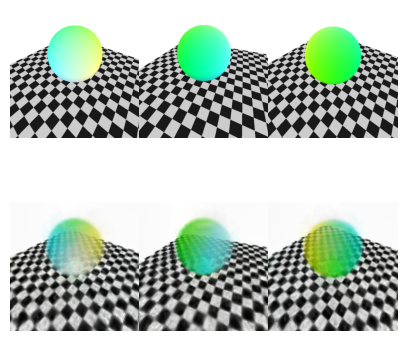

In [2]:
model = torch.load("diffoxels.pt", weights_only=False)
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(2,3, figsize=(5,5))

plt.subplots_adjust(hspace=0.0, wspace=0.0)
with torch.no_grad():
    for axtarget, axtest  in zip(ax[0], ax[1]):
        i = np.random.randint(num_poses)
        img = (model(origins[i].view(-1, 3), dirs[i].view(-1, 3)).view(512, 512, 3) * 255).to(torch.uint8).detach().to("cpu").numpy()
        axtest.imshow(img)
        axtest.axis("off")
        axtarget.axis("off")
        axtarget.imshow(colors[i].view(512, 512, 3).to("cpu").numpy())